In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib import cm
from tqdm import tqdm
import os
import torch
torch.cuda.empty_cache()
np.random.seed(2026)
torch.manual_seed(101)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(101)
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from numpy import linalg as la
from numpy import *
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
#from solver_sdmd_torch_gpu import KoopmanNNTorch, KoopmanSolverTorch


print (torch.__version__, torch.cuda.is_available())
print(torch.version.cuda)
print (torch.cuda.get_device_name())
# device= 'cpu'
device= 'cuda'

2.3.1 True
11.8
NVIDIA GeForce RTX 3070 Ti


In [2]:
import torch
torch.cuda.empty_cache()

In [3]:
def ou_process_1d(theta=1, mu=0, sigma=1, X0=0, n_steps=10000, n_eval=200, h=1e-5):
    """
    Simulates the Ornstein-Uhlenbeck process.
    
    Parameters:
    - theta: rate of mean reversion
    - mu: long-term mean of the process
    - sigma: volatility
    - X0: initial value
    - n_steps: number of steps in each evaluation
    - n_eval: number of evaluations
    - h: Integration step size
    
    Returns:
    - A numpy array containing the simulated values at each evaluation
    """
    X_eval = np.zeros(n_eval)
    X = X0
    
    for i in range(n_eval):
        for _ in range(n_steps):
            dW = np.sqrt(h) * np.random.randn()
            X = X + theta * (mu - X) * h + sigma * dW
        X_eval[i] = X
    
    return X_eval

## Setup the parameters
theta = 1
mu = 0
sigma = 0.1

In [4]:
# Generate m initial points from the domain space [-2, 2]
m = 20
n_eval = 200
n_steps = 1000
h = 1e-4
lag_time = n_steps * h
print("lag time: ", lag_time)
X0_values = np.linspace(-2, 2, m)

# Initialize the data_matrix
data_matrix = np.zeros((m, n_eval+1, 1))

# Simulate trajectories for each initial point and store them in the data_matrix
for i, X0 in tqdm(enumerate(X0_values), total=m, desc="Simulating trajectories"):
    X_eval = np.concatenate(([X0], ou_process_1d(theta=theta, mu=mu, sigma=sigma, X0=X0, n_steps=n_steps, n_eval=n_eval, h=h)))
    data_matrix[i, :, 0] = X_eval

# Print the shape of data_matrix
print("Shape of data_matrix:", data_matrix.shape)

# Extract data_X and data_Y from the data matrix
data_X = data_matrix[:, :-1, :]
data_Y = data_matrix[:, 1:, :]
print(f"Shape of data_X: {data_X.shape}")
print(f"Shape of data_Y: {data_Y.shape}")

# Reshape data_X and data_Y into a single column
X = data_X.reshape(-1, data_X.shape[2])  # 2D features
Y = data_Y.reshape(-1, data_X.shape[2])  # 2D targets
print(f"Shape of X: {X.shape}")
print(f"Shape of Y: {Y.shape}")

# Separate data into two parts: train and validation
len_all = X.shape[0]
data_x_train = X[:int(0.7*len_all)]
data_x_valid = X[int(0.7*len_all)+1:]

data_y_train = Y[:int(0.7*len_all)]
data_y_valid = Y[int(0.7*len_all)+1:]

data_train = [data_x_train, data_y_train]
data_valid = [data_x_valid, data_y_valid]

print(data_x_train.shape)

lag time:  0.1


Simulating trajectories:   0%|          | 0/20 [00:00<?, ?it/s]

Simulating trajectories:   5%|▌         | 1/20 [00:00<00:05,  3.39it/s]

Simulating trajectories:  10%|█         | 2/20 [00:00<00:05,  3.56it/s]

Simulating trajectories:  15%|█▌        | 3/20 [00:00<00:04,  3.58it/s]

...

Simulating trajectories:  90%|█████████ | 18/20 [00:05<00:00,  3.66it/s]

Simulating trajectories:  95%|█████████▌| 19/20 [00:05<00:00,  3.66it/s]

Simulating trajectories: 100%|██████████| 20/20 [00:05<00:00,  3.62it/s]

Simulating trajectories: 100%|██████████| 20/20 [00:05<00:00,  3.60it/s]

Shape of data_matrix: (20, 201, 1)
Shape of data_X: (20, 200, 1)
Shape of data_Y: (20, 200, 1)
Shape of X: (4000, 1)
Shape of Y: (4000, 1)
(2800, 1)


In [5]:
from solver_edmd_torch_gpu import KoopmanNNTorch, EDMDSolverTorch
#### EDMD Test ####
checkpoint_file= 'ou1d_v2_edmd_ckpt.torch'

basis_function = KoopmanNNTorch(input_size=1, layer_sizes=[20, 20], n_psi_train=20).to(device)

solver = EDMDSolverTorch(
    dic=basis_function,
    target_dim=np.shape(data_x_train)[-1],
    reg=0.1,
    checkpoint_file=checkpoint_file,
    batch_size=32
)

data_x_train_tensor = torch.DoubleTensor(data_x_train).to (device)#, requieres_grad= True)#, dtype=tf.float64)
data_y_train_tensor = torch.DoubleTensor(data_y_train).to (device)#, requires_grad= True)#, dtype=tf.float64)

In [6]:
solver.build_with_edmd(
    data_train=data_train,
    data_valid=data_valid,
    epochs=6,
    batch_size=256,
    lr=1e-5,
    log_interval=10,
    lr_decay_factor=0.8
)

Outer Epoch 1/6
Epoch: 1 	Training Loss: 0.000078 val loss: 0.000093
saving, val loss enhanced: 9.267115709580947e-05 1000000000000000.0
Epoch: 2 	Training Loss: 0.000077 val loss: 0.000093


Epoch: 3 	Training Loss: 0.000077 val loss: 0.000093
Outer Epoch 2/6
Epoch: 1 	Training Loss: 0.000076 val loss: 0.000092
saving, val loss enhanced: 9.158449689619475e-05 9.267115709580947e-05
Epoch: 2 	Training Loss: 0.000076 val loss: 0.000092
Epoch: 3 	Training Loss: 0.000076 val loss: 0.000092
Outer Epoch 3/6


Epoch: 1 	Training Loss: 0.000075 val loss: 0.000091
saving, val loss enhanced: 9.052874480618808e-05 9.158449689619475e-05
Epoch: 2 	Training Loss: 0.000075 val loss: 0.000091
Epoch: 3 	Training Loss: 0.000075 val loss: 0.000091
Outer Epoch 4/6


Epoch: 1 	Training Loss: 0.000074 val loss: 0.000089
saving, val loss enhanced: 8.947724732540256e-05 9.052874480618808e-05
Epoch: 2 	Training Loss: 0.000074 val loss: 0.000090


Epoch: 3 	Training Loss: 0.000074 val loss: 0.000090
Outer Epoch 5/6
Epoch: 1 	Training Loss: 0.000073 val loss: 0.000089
saving, val loss enhanced: 8.850812479702889e-05 8.947724732540256e-05
Epoch: 2 	Training Loss: 0.000073 val loss: 0.000089


Epoch: 3 	Training Loss: 0.000073 val loss: 0.000089
Outer Epoch 6/6
Epoch: 1 	Training Loss: 0.000072 val loss: 0.000088
saving, val loss enhanced: 8.752453509779937e-05 8.850812479702889e-05
Epoch: 2 	Training Loss: 0.000072 val loss: 0.000088


Epoch: 3 	Training Loss: 0.000072 val loss: 0.000088


In [7]:
# Results from solver_edmd
evalues = solver.eigenvalues.T
efuns = solver.eigenfunctions(X)
N_dict = np.shape(evalues)[0]
Koopman_matrix_K = solver.K
outputs = {
    'efuns': efuns,
    'evalues': evalues,
    'N_dict': N_dict,
    'K': Koopman_matrix_K
    }

[ 2.0000e-04 -9.5150e-01 -2.8862e+00 -4.8544e+00]


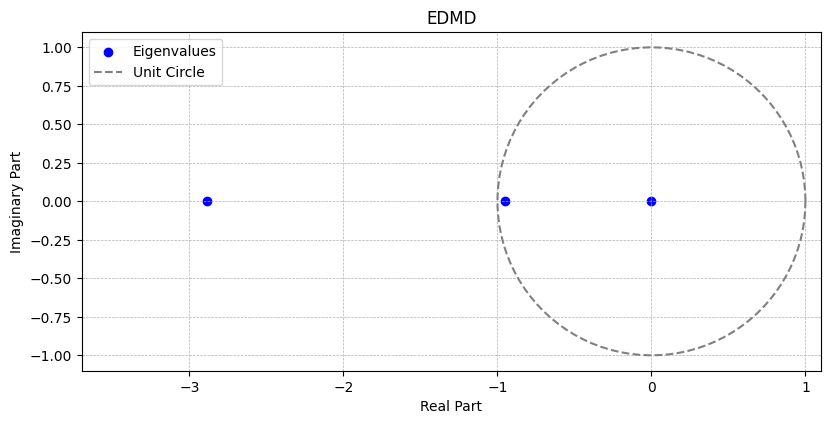

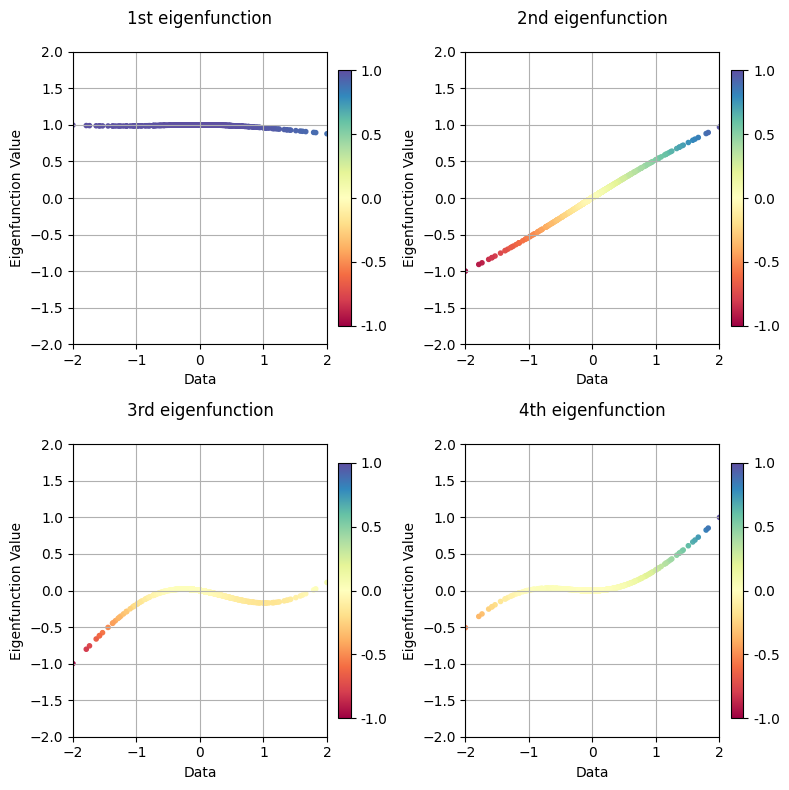

In [8]:
# Take ln values of the eigenvalues and divide by 0.1
# ln_evalues = np.log(evalues[:4]) / lag_time
ln_evalues = (evalues[:4]-1) / lag_time
ln_evalues_display = np.real_if_close(ln_evalues, tol=1000).real

print(np.round(ln_evalues_display, 4))

## Plot eigenvalues on unit circle
# Assuming evalues is a numpy array of complex numbers
real_parts = ln_evalues_display
imag_parts = np.zeros_like(real_parts)

# Create the plot
plt.figure(figsize=(9.6, 4.4))
plt.scatter(real_parts, imag_parts, color='blue', label='Eigenvalues')

# Draw a unit circle for reference
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), linestyle='--', color='grey', label='Unit Circle')

plt.title('EDMD')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.xlim(-3.7, 1.1)
plt.ylim(-1.1, 1.1)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

## Plot eigenfunctions
# Get the real part of eigenfunctions and normalize them
phi = np.real(efuns)

# Use the entire efuns instead of slicing
for i in range(len(evalues)):
    phi[:, i] = phi[:, i] / np.max(np.abs(phi[:, i]))

# Create a plot with 2x2 layout
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
titles = ['1st eigenfunction', '2nd eigenfunction', '3rd eigenfunction', '4th eigenfunction']

# Determine global min and max values for the eigenfunctions for a uniform scale
vmin = np.min(phi)
vmax = np.max(phi)
cbar_ticks = np.linspace(vmin, vmax, 5)

# Flatten the 2D array of axes for easy iteration
axs_flat = axs.flatten()

for i, (ax, title) in enumerate(zip(axs_flat, titles)):
    scatter = ax.scatter(X, phi[:, i], c=phi[:, i], cmap='Spectral', marker='.', vmin=vmin, vmax=vmax)
    ax.set_title(title, pad=20)
    ax.set_xlabel('Data')
    ax.set_ylabel('Eigenfunction Value')
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    cbar = fig.colorbar(scatter, ax=ax, orientation='vertical', fraction=0.046, pad=0.04, ticks=cbar_ticks)
    cbar.set_ticklabels([f"{tick:.1f}" for tick in cbar_ticks])
    ax.grid()
# fig.suptitle('SDMD', fontsize=20)
plt.tight_layout()
plt.show()

In [9]:
from solver_sdmd_torch_gpu import KoopmanNNTorch, KoopmanSolverTorch
#### SDMD Test ####
checkpoint_file= 'ou1d_v2_sdmd_ckpt.torch'

np.random.seed(101)
torch.manual_seed(101)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(101)

basis_function = KoopmanNNTorch(input_size=1, layer_sizes=[20, 20], n_psi_train=20).to(device)

solver = KoopmanSolverTorch(dic=basis_function, # Replace 'koopman_nn' by 'dic' if you use the original solver_edmdvar
                       target_dim=np.shape(data_x_train)[-1],
                       reg=0.1,  checkpoint_file= checkpoint_file, fnn_checkpoint_file= 'ou1d_v2_sdmd_fnn_ckpt.torch', a_b_file= 'ou1d_v2_sdmd_a_b.jbl',
                generator_batch_size= 16, fnn_batch_size= 32, delta_t= lag_time)

data_x_train_tensor = torch.DoubleTensor(data_x_train).to (device)#, requieres_grad= True)#, dtype=tf.float64)
data_y_train_tensor = torch.DoubleTensor(data_y_train).to (device)#, requires_grad= True)#, dtype=tf.float64)


In [10]:
solver.build_with_generator(
    data_train=data_train,
    data_valid=data_valid,
    epochs=8,
    batch_size=256,
    lr=5e-5,
    log_interval=10,
    lr_decay_factor=.8,
    lambda_reg=0.01,
    inner_epochs=3
    )


Epoch: 1 	Training Loss: 0.026226 	Validation Loss: 0.018538
Saving model, validation loss improved: 0.018538 < 10000.000000
Epoch: 2 	Training Loss: 0.013364 	Validation Loss: 0.010810
Saving model, validation loss improved: 0.010810 < 0.018538


Epoch: 3 	Training Loss: 0.008557 	Validation Loss: 0.007373
Saving model, validation loss improved: 0.007373 < 0.010810
Epoch: 4 	Training Loss: 0.006498 	Validation Loss: 0.006054
Saving model, validation loss improved: 0.006054 < 0.007373


Epoch: 5 	Training Loss: 0.005803 	Validation Loss: 0.005530
Saving model, validation loss improved: 0.005530 < 0.006054
Epoch: 6 	Training Loss: 0.005404 	Validation Loss: 0.005275
Saving model, validation loss improved: 0.005275 < 0.005530


Epoch: 7 	Training Loss: 0.005331 	Validation Loss: 0.005269
Saving model, validation loss improved: 0.005269 < 0.005275
Epoch: 8 	Training Loss: 0.005177 	Validation Loss: 0.005101
Saving model, validation loss improved: 0.005101 < 0.005269


Epoch: 9 	Training Loss: 0.005168 	Validation Loss: 0.005100
Saving model, validation loss improved: 0.005100 < 0.005101
Epoch: 10 	Training Loss: 0.005129 	Validation Loss: 0.005012
Saving model, validation loss improved: 0.005012 < 0.005100


...

Processing batches:  75%|███████▌  | 132/175 [00:00<00:00, 184.12batch/s]

Processing batches:  87%|████████▋ | 152/175 [00:00<00:00, 188.86batch/s]

Processing batches:  98%|█████████▊| 172/175 [00:00<00:00, 189.00batch/s]

Processing batches: 100%|██████████| 175/175 [00:00<00:00, 181.34batch/s]

Epoch: 1 	Training Loss: 0.000053 val loss: 0.000053
Saving model, val loss improved from 0.000054 to 0.000053
Epoch: 2 	Training Loss: 0.000053 val loss: 0.000053
Saving model, val loss improved from 0.000053 to 0.000053
EarlyStopping counter: 1 out of 7
Epoch: 3 	Training Loss: 0.000052 val loss: 0.000052
Saving model, val loss improved from 0.000053 to 0.000052
EarlyStopping counter: 2 out of 7
Epoch 8 time: 1.19 seconds


In [11]:
# Results from solver_edmd/solver_resdmd
evalues = solver.eigenvalues.T
efuns = solver.eigenfunctions(X)
N_dict = np.shape(evalues)[0]
Koopman_matrix_K = solver.K
outputs = {
    'efuns': efuns,
    'evalues': evalues,
    'N_dict': N_dict,
    'K': Koopman_matrix_K
    }

[ 1.0000e-04 -9.3650e-01 -1.8795e+00 -3.0046e+00]


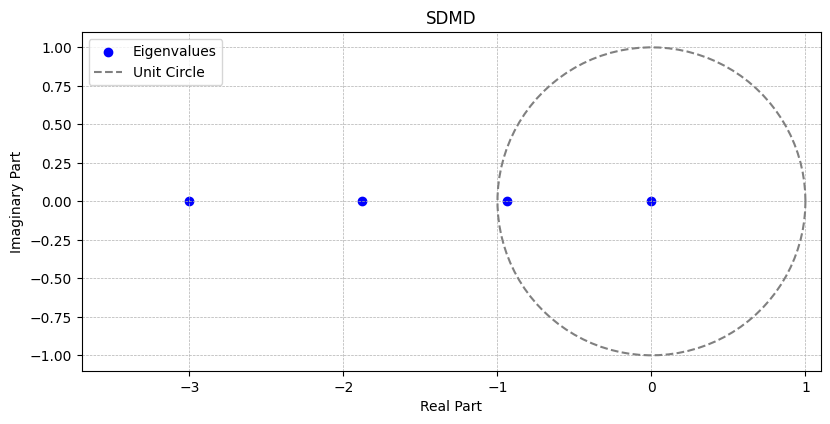

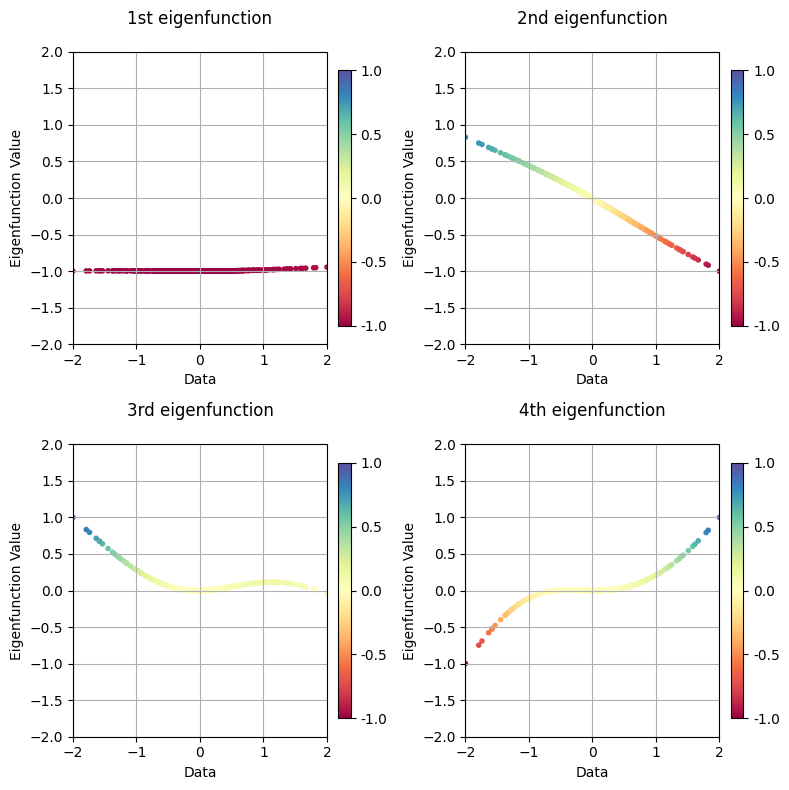

In [12]:
# Take ln values of the eigenvalues and divide by 0.1
# ln_evalues = np.log(evalues[:4]) / lag_time
ln_evalues = (evalues[:4]-1) / lag_time
ln_evalues_display = np.real_if_close(ln_evalues, tol=1000).real

print(np.round(ln_evalues_display, 4))

## Plot eigenvalues on unit circle
# Assuming evalues is a numpy array of complex numbers
real_parts = ln_evalues_display
imag_parts = np.zeros_like(real_parts)

# Create the plot
plt.figure(figsize=(9.6, 4.4))
plt.scatter(real_parts, imag_parts, color='blue', label='Eigenvalues')

# Draw a unit circle for reference
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), linestyle='--', color='grey', label='Unit Circle')

plt.title('SDMD')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.xlim(-3.7, 1.1)
plt.ylim(-1.1, 1.1)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

## Plot eigenfunctions
# Get the real part of eigenfunctions and normalize them
phi = np.real(efuns)

# Use the entire efuns instead of slicing
for i in range(len(evalues)):
    phi[:, i] = phi[:, i] / np.max(np.abs(phi[:, i]))

# Create a plot with 2x2 layout
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
titles = ['1st eigenfunction', '2nd eigenfunction', '3rd eigenfunction', '4th eigenfunction']

# Determine global min and max values for the eigenfunctions for a uniform scale
vmin = np.min(phi)
vmax = np.max(phi)
cbar_ticks = np.linspace(vmin, vmax, 5)

# Flatten the 2D array of axes for easy iteration
axs_flat = axs.flatten()

for i, (ax, title) in enumerate(zip(axs_flat, titles)):
    scatter = ax.scatter(X, phi[:, i], c=phi[:, i], cmap='Spectral', marker='.', vmin=vmin, vmax=vmax)
    ax.set_title(title, pad=20)
    ax.set_xlabel('Data')
    ax.set_ylabel('Eigenfunction Value')
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    cbar = fig.colorbar(scatter, ax=ax, orientation='vertical', fraction=0.046, pad=0.04, ticks=cbar_ticks)
    cbar.set_ticklabels([f"{tick:.1f}" for tick in cbar_ticks])
    ax.grid()
# fig.suptitle('SDMD', fontsize=20)
plt.tight_layout()
plt.show()

In [13]:
from solver_gedmd_torch_gpu import KoopmanNNTorch as KoopmanNNTorch_g
from solver_gedmd_torch_gpu import  KoopmanSolverTorch as KoopmanSolverTorch_g
#### gEDMD Test ####
checkpoint_file_g= 'ou1d_v2_gedmd_ckpt.torch'
basis_function_g = KoopmanNNTorch_g(input_size=1, layer_sizes=[20, 20], n_psi_train=20).to(device)

solver_g = KoopmanSolverTorch_g(dic=basis_function_g, # Replace 'koopman_nn' by 'dic' if you use the original solver_edmdvar
                       target_dim=np.shape(data_x_train)[-1],
                       reg=0.1,  checkpoint_file= checkpoint_file_g, fnn_checkpoint_file= 'ou1d_v2_gedmd_fnn_ckpt.torch',  a_b_file= 'ou1d_v2_gedmd_a_b.jbl',
                generator_batch_size= 16, fnn_batch_size= 32)


In [14]:
solver_g.build_with_generator(
    data_train=data_train,
    data_valid=data_valid,
    epochs=8,
    batch_size=256,
    lr=1e-5,
    log_interval=10,
    lr_decay_factor=.8,
    lambda_reg=0.01,
    )


Epoch: 1 	Training Loss: 0.019019 	Validation Loss: 0.014262
Saving model, validation loss improved: 0.014262 < 10000.000000
Epoch: 2 	Training Loss: 0.009119 	Validation Loss: 0.005218
Saving model, validation loss improved: 0.005218 < 0.014262


Epoch: 3 	Training Loss: 0.007186 	Validation Loss: 0.003029
Saving model, validation loss improved: 0.003029 < 0.005218
Epoch: 4 	Training Loss: 0.006749 	Validation Loss: 0.002386
Saving model, validation loss improved: 0.002386 < 0.003029


Epoch: 5 	Training Loss: 0.006598 	Validation Loss: 0.002135
Saving model, validation loss improved: 0.002135 < 0.002386
Epoch: 6 	Training Loss: 0.006445 	Validation Loss: 0.001837
Saving model, validation loss improved: 0.001837 < 0.002135


Epoch: 7 	Training Loss: 0.006345 	Validation Loss: 0.001779
Saving model, validation loss improved: 0.001779 < 0.001837
Epoch: 8 	Training Loss: 0.006247 	Validation Loss: 0.001538
Saving model, validation loss improved: 0.001538 < 0.001779


Epoch: 9 	Training Loss: 0.006246 	Validation Loss: 0.001437
Saving model, validation loss improved: 0.001437 < 0.001538
Epoch: 10 	Training Loss: 0.006167 	Validation Loss: 0.001388
Saving model, validation loss improved: 0.001388 < 0.001437


...

Processing batches:  85%|████████▌ | 149/175 [00:00<00:00, 178.08batch/s]

Processing batches:  97%|█████████▋| 169/175 [00:00<00:00, 182.04batch/s]

Processing batches: 100%|██████████| 175/175 [00:01<00:00, 174.46batch/s]

EarlyStopping counter: 7 out of 7
Early stopping triggered


([0.0011660586466840097,
  0.0011661702640277229,
  0.0011662818373820794,
  0.0011663933648020106,
  0.0011665048443167414,
  0.0011666162739395033,
  0.0011667276516808857,
  0.0011668389755623717],
 0.0011660586466840097)

In [15]:
solver_g.eig_decomp()  # Do spectral decomposition to generate eigenvalues and eigenvectors

evalues = solver_g.eigenvalues.T
efuns = solver_g.eigenfunctions(X)
N_dict = np.shape(evalues)[0]
Psi_X = solver_g.get_Psi_X()
Psi_Y = solver_g.get_Psi_Y()
outputs = {
    'efuns': efuns,
    'evalues': evalues,
    'N_dict': N_dict
}

[ 0.     -2.3989 -1.9055 -0.8098]


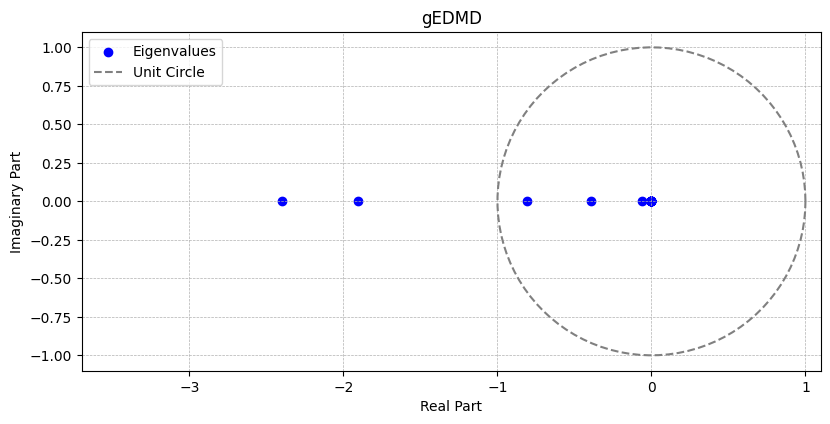

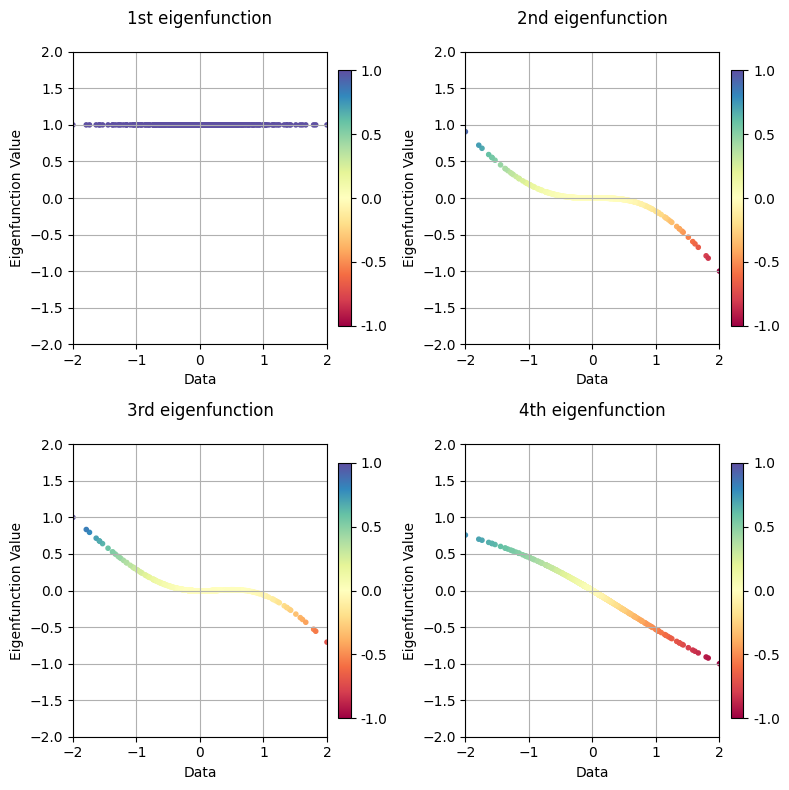

In [16]:
evalues_display = np.real_if_close(evalues, tol=1000).real
print(np.round(evalues_display[:4], 4))

## Plot eigenvalues on unit circle
# Assuming evalues is a numpy array of complex numbers
real_parts = evalues_display
imag_parts = np.zeros_like(real_parts)

# Create the plot
plt.figure(figsize=(9.6, 4.4))
plt.scatter(real_parts, imag_parts, color='blue', label='Eigenvalues')

# Draw a unit circle for reference
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), linestyle='--', color='grey', label='Unit Circle')

plt.title('gEDMD')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.xlim(-3.7, 1.1)
plt.ylim(-1.1, 1.1)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

## Plot eigenfunctions
# Get the real part of eigenfunctions and normalize them
phi = np.real(efuns)

# Use the entire efuns instead of slicing
for i in range(len(evalues)):
    phi[:, i] = phi[:, i] / np.max(np.abs(phi[:, i]))

# Create a plot with 2x2 layout
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
titles = ['1st eigenfunction', '2nd eigenfunction', '3rd eigenfunction', '4th eigenfunction']

# Determine global min and max values for the eigenfunctions for a uniform scale
vmin = np.min(phi)
vmax = np.max(phi)
cbar_ticks = np.linspace(vmin, vmax, 5)

# Flatten the 2D array of axes for easy iteration
axs_flat = axs.flatten()

for i, (ax, title) in enumerate(zip(axs_flat, titles)):
    scatter = ax.scatter(X, phi[:, i], c=phi[:, i], cmap='Spectral', marker='.', vmin=vmin, vmax=vmax)
    ax.set_title(title, pad=20)
    ax.set_xlabel('Data')
    ax.set_ylabel('Eigenfunction Value')
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    cbar = fig.colorbar(scatter, ax=ax, orientation='vertical', fraction=0.046, pad=0.04, ticks=cbar_ticks)
    cbar.set_ticklabels([f"{tick:.1f}" for tick in cbar_ticks])
    ax.grid()
# fig.suptitle('gEDMD', fontsize=20)
plt.tight_layout()
plt.show()